<a href="https://colab.research.google.com/github/KrisDA-1/ML_UrbanCrime/blob/main/CrimePredictionLondon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PROJECT:
          "A Comparative Analysis of Supervised Machine Learning technologies for Crime Risk Prediction Using Large-Scale Urban Data: A London Case Study"
#####AUTHOR:  Krisnha Rueda


In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve, ConfusionMatrixDisplay)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install shap lime -q
import shap
from lime.lime_tabular import LimeTabularExplainer

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

PROJECT_CONFIG = {
    'target_audience': 'University students & staff',
    'output_dir': '/content/drive/MyDrive/Dissertation/Output/',
    'random_state': 42
}
os.makedirs(PROJECT_CONFIG['output_dir'], exist_ok=True)
SEED = PROJECT_CONFIG['random_state']

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# =============================================================================
# 2. LOAD & VALIDATE DATA
# =============================================================================

DATA_PATH = Path("/content/drive/MyDrive/Dissertation/")

print("Loading datasets...")
try:
    knife_df = pd.read_csv(DATA_PATH / "M1045_KnifeCrimeData.csv")
    other_df = pd.read_csv(DATA_PATH / "M1045_OtherCrimeData.csv")
    tno_df   = pd.read_csv(DATA_PATH / "M1045_TNOCrimeData.csv", usecols=range(12))

    print(f"  Knife: {knife_df.shape}  |  Other: {other_df.shape}  |  TNO: {tno_df.shape}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"❌ Missing file: {e}")

Loading datasets...
  Knife: (59431, 12)  |  Other: (415533, 12)  |  TNO: (859241, 12)


In [4]:
# =============================================================================
# 3. STANDARDISE COLUMN NAMES
# =============================================================================

COLUMN_MAP_KNIFE_OTHER = {
    'Month_Year': 'month_year',
    'Area Type':  'area_type',
    'Borough_SNT': 'borough',
    'Area Name':  'area_name',
    'Area Code':  'area_code',
    'Crime Type': 'crime_type',
    'Crime Subtype': 'crime_subtype',
    'Measure':    'measure',
    'Financial Year': 'financial_year',
    'FY_FYIndex': 'fy_index',
    'Count':      'count',
    'Refresh Date': 'refresh_date'
}

COLUMN_MAP_TNO = {
    'Month_Year': 'month_year',
    'Area Type':  'area_type',
    'Borough_SNT': 'borough',
    'Area name':  'area_name',     # note: lowercase 'n' in source
    'Area code':  'area_code',     # note: lowercase 'c' in source
    'Offence Group': 'crime_type',
    'Offence Subgroup': 'crime_subtype',
    'Measure':    'measure',
    'Financial Year': 'financial_year',
    'FY_FYIndex': 'fy_index',
    'Count':      'count',
    'Refresh Date': 'refresh_date'
}

knife_df = knife_df.rename(columns=COLUMN_MAP_KNIFE_OTHER)
other_df = other_df.rename(columns=COLUMN_MAP_KNIFE_OTHER)
tno_df   = tno_df.rename(columns=COLUMN_MAP_TNO)

print("Column names standardised.")

Column names standardised.


In [5]:
# =============================================================================
# 4. FILTER TO BOROUGH-LEVEL OFFENCES ONLY
# =============================================================================
knife_df = knife_df[(knife_df['area_type'] == 'Borough') &
                     (knife_df['measure'] == 'Offences')].copy()

other_df = other_df[(other_df['area_type'] == 'Borough') &
                     (other_df['measure'] == 'Offences')].copy()

tno_df = tno_df[(tno_df['area_type'] == 'Borough') &
                 (tno_df['measure'] == 'Offences')].copy()

# Drop pseudo-boroughs that are not real London boroughs
EXCLUDE_BOROUGHS = {'Aviation Security', 'N/K', 'Unknown'}
for df in [knife_df, other_df, tno_df]:
    df.drop(df[df['borough'].isin(EXCLUDE_BOROUGHS)].index, inplace=True)

print(f"After filtering -> Knife: {len(knife_df)}  |  Other: {len(other_df)}  |  TNO: {len(tno_df)}")


After filtering -> Knife: 6954  |  Other: 24369  |  TNO: 42551


In [6]:
# =============================================================================
# 5. CONVERT DATA FORMAT AND EXTRACT TEMPORAL FEATURES
# =============================================================================
for df in [knife_df, other_df, tno_df]:
    df['date'] = pd.to_datetime(df['month_year'], format='%d/%m/%Y')
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month

print(f"Date range: {knife_df['date'].min().date()} to {knife_df['date'].max().date()}")


Date range: 2022-03-01 to 2026-02-01


In [7]:
# =============================================================================
# 6. ASSIGN CRIME GROUPS AND HIERARCHICAL RISK CATEGORIES
# =============================================================================
# Each record is mapped to a crime_group (descriptive label) and a
# risk_category (hierarchical level used for feature engineering).

# --- 6a. Knife Crime (all rows are knife crime by definition) ---
knife_df['crime_group']   = 'Knife Crime'
knife_df['risk_category'] = 'KNIFE_CRIME'

# --- 6b. Other Crime (Gun, Domestic Abuse, Hate Crime, Miscellaneous) ---
# Mobile phone robbery/theft subtypes are recorded under crime_type "Miscalleneous"
# but should be categorised as Theft for student-safety relevance.

MOBILE_THEFT_SUBTYPES = {'ROBBERY MOBILE PHONE', 'THEFT PERSON - MOBILE PHONE'}

def map_other_crime(row):
    ct = str(row['crime_type']).upper()
    cs = str(row['crime_subtype']).upper()
    if cs in MOBILE_THEFT_SUBTYPES:
        return 'Theft & Robbery Mobile Phone'
    if any(kw in ct for kw in ['GUN CRIME', 'LETHAL BARREL', 'FIREARM']):
        return 'Gun Crime'
    if 'DOMESTIC' in ct:
        return 'Domestic Abuse'
    if 'HATE' in ct:
        return 'Hate Crime'
    return 'Miscellaneous'

other_df['crime_group'] = other_df.apply(map_other_crime, axis=1)


In [8]:
# --- 6c. TNO Crime ---
def map_tno_crime(offence_group):
    og = str(offence_group).upper()
    if 'SEXUAL' in og:
        return 'Sexual Offences'
    if 'THEFT' in og:
        return 'Theft'
    if any(kw in og for kw in ['VIOLENCE AGAINST', 'POSSESSION OF WEAPONS',
                                'ROBBERY']):
        return 'Violent Offences'
    if any(kw in og for kw in ['ARSON', 'CRIMINAL DAMAGE', 'BURGLARY',
                                'VEHICLE OFFENCES', 'PUBLIC ORDER']):
        return 'Property & Public Order'
    if any(kw in og for kw in ['DRUG', 'FRAUD']):
        return 'Drugs & Fraud'
    return 'Miscellaneous'

tno_df['crime_group'] = tno_df['crime_type'].apply(map_tno_crime)

In [9]:
# --- 6d. Hierarchical risk mapping (student-safety priority) ---
RISK_HIERARCHY = {
    'Sexual Offences':                                'SEXUAL_OFFENCES',
    'Knife Crime':                                    'KNIFE_CRIME',
    'Gun Crime':                                      'WEAPON_CRIME',
    'Theft':                                          'THEFT_ROBBERY',
    'Theft & Robbery Mobile Phone':                   'THEFT_ROBBERY',
    'Hate Crime':                                     'OTHER_VIOLENT_CRIME',
    'Violent Offences':                               'OTHER_VIOLENT_CRIME',
    'Property & Public Order':                        'OTHER',
    'Drugs & Fraud':                                  'DRUGS_FRAUD',
    'Domestic Abuse':                                 'OTHER',
    'Miscellaneous':                                  'OTHER'
}

for df in [knife_df, other_df, tno_df]:
    df['risk_category'] = df['crime_group'].map(RISK_HIERARCHY)

In [10]:
# Validation
print("\nCrime group distribution across all datasets:")
combined_groups = pd.concat([
    knife_df[['crime_group', 'risk_category']],
    other_df[['crime_group', 'risk_category']],
    tno_df[['crime_group', 'risk_category']]
])
print(combined_groups.groupby(['risk_category', 'crime_group']).size()
      .reset_index(name='n_rows')
      .sort_values('n_rows', ascending=False)
      .to_string(index=False))


Crime group distribution across all datasets:
      risk_category                  crime_group  n_rows
              OTHER      Property & Public Order   18178
OTHER_VIOLENT_CRIME                   Hate Crime   12155
OTHER_VIOLENT_CRIME             Violent Offences   10154
        KNIFE_CRIME                  Knife Crime    6954
      THEFT_ROBBERY                        Theft    6242
              OTHER                Miscellaneous    4793
        DRUGS_FRAUD                Drugs & Fraud    3292
              OTHER               Domestic Abuse    3242
      THEFT_ROBBERY Theft & Robbery Mobile Phone    3204
    SEXUAL_OFFENCES              Sexual Offences    3123
       WEAPON_CRIME                    Gun Crime    2537


In [11]:
# =============================================================================
# 7. COMBINE DATASETS & AGGREGATE TO BOROUGH-MONTH LEVEL
# =============================================================================
# Select only the columns needed, then concatenate.
KEEP_COLS = ['borough', 'year', 'month', 'date', 'crime_group',
             'risk_category', 'count']

df_all = pd.concat([
    knife_df[KEEP_COLS],
    other_df[KEEP_COLS],
    tno_df[KEEP_COLS]
], ignore_index=True)

print(f"\nCombined dataset: {df_all.shape[0]:,} rows across "
      f"{df_all['borough'].nunique()} boroughs, "
      f"{df_all['date'].nunique()} months")


Combined dataset: 73,874 rows across 33 boroughs, 48 months


In [12]:
# --- Risk-priority scoring ---
RISK_PRIORITY = {
    'KNIFE_CRIME': 3.5, 'SEXUAL_OFFENCES': 5.0, 'WEAPON_CRIME': 4.0,
    'OTHER_VIOLENT_CRIME': 2.5, 'THEFT_ROBBERY': 4.5,
    'DRUGS_FRAUD': 0.8, 'OTHER': 0.5
}
df_all['risk_score'] = df_all['risk_category'].map(RISK_PRIORITY).fillna(0.5)


In [13]:
# Borough-month aggregation
df_agg = (df_all
    .groupby(['borough', 'year', 'month', 'date'])
    .agg(
        total_crime    = ('count', 'sum'),
        n_records      = ('count', 'count'),
        mean_risk      = ('risk_score', 'mean'),
        max_risk       = ('risk_score', 'max'),
        top_risk_cat   = ('risk_category',
                          lambda x: x.value_counts().index[0])
    )
    .reset_index()
    .sort_values(['borough', 'date'])
    .reset_index(drop=True)
)

print(f"Aggregated dataset: {df_agg.shape[0]:,} borough-month observations")


Aggregated dataset: 1,584 borough-month observations


In [14]:
# =============================================================================
# 8. TARGET VARIABLE CREATION
# =============================================================================
df_agg['borough_rolling_mean'] = (df_agg.groupby('borough')['total_crime']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=3).mean()))
df_agg['borough_rolling_std'] = (df_agg.groupby('borough')['total_crime']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=3).std()))

df_agg['crime_deviation'] = ((df_agg['total_crime'] - df_agg['borough_rolling_mean'])
                              / df_agg['borough_rolling_std'])
df_agg['crime_deviation'] = df_agg['crime_deviation'].replace([np.inf, -np.inf], 0)

# Target: 1 if crime is >1 SD above the borough's own recent baseline
df_agg['high_risk'] = (df_agg['crime_deviation'] > 1.0).astype(int)

# Drop rows where rolling baseline cannot be computed
df_agg = df_agg.dropna(subset=['borough_rolling_mean']).reset_index(drop=True)

class_dist = df_agg['high_risk'].value_counts(normalize=True)
print(f"\nTarget: borough-relative crime surge (>1 SD above rolling baseline)")
print(f"  Normal (0): {class_dist.get(0, 0):.1%}")
print(f"  Surge  (1): {class_dist.get(1, 0):.1%}")


Target: borough-relative crime surge (>1 SD above rolling baseline)
  Normal (0): 78.4%
  Surge  (1): 21.6%


In [15]:
# =============================================================================
# 9. FEATURE ENGINEERING
# =============================================================================
print("\nEngineering features...")

# Temporal: season
df_agg['season'] = df_agg['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Lagged crime counts (capture magnitude context)
df_agg['crime_lag1'] = df_agg.groupby('borough')['total_crime'].shift(1)
df_agg['crime_lag2'] = df_agg.groupby('borough')['total_crime'].shift(2)
df_agg['crime_lag3'] = df_agg.groupby('borough')['total_crime'].shift(3)


Engineering features...


In [16]:
# Rolling 3-month average (lagged to avoid leakage)
df_agg['crime_roll3'] = (df_agg.groupby('borough')['total_crime']
                         .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))

# Trend: percentage change from previous month
df_agg['crime_trend'] = (df_agg.groupby('borough')['total_crime']
                         .pct_change())

# Deviation lags: whether the borough was surging in recent months
df_agg['dev_lag1'] = df_agg.groupby('borough')['crime_deviation'].shift(1)
df_agg['dev_lag2'] = df_agg.groupby('borough')['crime_deviation'].shift(2)

In [17]:
#Ratio of last month's crime to rolling average (momentum indicator)
df_agg['lag1_vs_roll3'] = df_agg['crime_lag1'] / df_agg['crime_roll3']
df_agg['lag1_vs_roll3'] = df_agg['lag1_vs_roll3'].replace([np.inf, -np.inf], 1).fillna(1)

# Year-over-year seasonality: same month last year
df_agg['crime_same_month_ly'] = (df_agg.groupby(['borough', 'month'])
                                  ['total_crime'].shift(1))
df_agg['yoy_change'] = ((df_agg['crime_lag1'] - df_agg['crime_same_month_ly'])
                          / df_agg['crime_same_month_ly'])
df_agg['yoy_change'] = df_agg['yoy_change'].replace([np.inf, -np.inf], 0).fillna(0)

# Drop rows where lag/deviation features are NaN
rows_before = len(df_agg)
df_agg = df_agg.dropna(subset=['crime_lag1', 'dev_lag1']).reset_index(drop=True)
print(f"  Dropped {rows_before - len(df_agg)} rows with insufficient history")

  Dropped 33 rows with insufficient history


In [18]:
# Lagged features (prevent data leakage - use only past information)
df_agg['crime_lag1'] = (df_agg.groupby('borough')['total_crime']
                        .shift(1))
df_agg['crime_lag2'] = (df_agg.groupby('borough')['total_crime']
                        .shift(2))
df_agg['crime_lag3'] = (df_agg.groupby('borough')['total_crime']
                        .shift(3))

# Rolling 3-month average (lagged to avoid leakage)
df_agg['crime_roll3'] = (df_agg.groupby('borough')['total_crime']
                         .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))

# Trend: percentage change from previous month
df_agg['crime_trend'] = (df_agg.groupby('borough')['total_crime']
                         .pct_change())

# Drop rows where lag features are NaN (first months per borough)
rows_before = len(df_agg)
df_agg = df_agg.dropna(subset=['crime_lag1']).reset_index(drop=True)
print(f"  Dropped {rows_before - len(df_agg)} rows with insufficient history")

# Replace any remaining inf values from pct_change
df_agg['crime_trend'] = df_agg['crime_trend'].replace([np.inf, -np.inf], 0)

# Final feature set
FEATURE_COLS = ['borough', 'month', 'season', 'mean_risk', 'max_risk',
                'top_risk_cat', 'crime_lag1', 'crime_lag2', 'crime_lag3',
                'crime_roll3', 'crime_trend']

X = df_agg[FEATURE_COLS].copy()
y = df_agg['high_risk'].copy()

print(f"  Feature matrix: {X.shape}  |  Target: {y.shape}")


  Dropped 33 rows with insufficient history
  Feature matrix: (1419, 11)  |  Target: (1419,)


In [19]:
# Replace any remaining inf values
df_agg['crime_trend'] = df_agg['crime_trend'].replace([np.inf, -np.inf], 0)

# Final feature set (15 features across 5 domains)
FEATURE_COLS = ['borough', 'month', 'season', 'mean_risk', 'max_risk',
                'top_risk_cat', 'crime_lag1', 'crime_lag2', 'crime_lag3',
                'crime_roll3', 'crime_trend',
                'dev_lag1', 'dev_lag2', 'lag1_vs_roll3', 'yoy_change']

X = df_agg[FEATURE_COLS].copy()
y = df_agg['high_risk'].copy()

print(f"  Feature matrix: {X.shape}  |  Target: {y.shape}")


  Feature matrix: (1419, 15)  |  Target: (1419,)


In [20]:
# =============================================================================
# 10. PREPROCESSING PIPELINE
# =============================================================================
categorical_features = ['borough', 'season', 'top_risk_cat']
numeric_features     = ['month', 'mean_risk', 'max_risk',
                        'crime_lag1', 'crime_lag2', 'crime_lag3',
                        'crime_roll3', 'crime_trend',
                        'dev_lag1', 'dev_lag2', 'lag1_vs_roll3', 'yoy_change']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), numeric_features)
    ]
)


In [21]:
# =============================================================================
# 11. TRAIN / TEST SPLIT
# =============================================================================
# Sort by date to ensure temporal ordering, then split 80/20
df_agg = df_agg.sort_values('date').reset_index(drop=True)
X = df_agg[FEATURE_COLS].copy()
y = df_agg['high_risk'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False   # preserves chronological order
)

split_date = df_agg.loc[X_test.index[0], 'date']
print(f"\nTrain: {len(X_train):,} rows (up to {split_date.date()})")
print(f"Test:  {len(X_test):,} rows (from {split_date.date()} onward)")



Train: 1,135 rows (up to 2025-06-01)
Test:  284 rows (from 2025-06-01 onward)


In [22]:
# =============================================================================
# 12. MODEL DEFINITIONS
# =============================================================================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=SEED,
        max_depth=10, min_samples_leaf=5, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=2,
        min_samples_leaf=15, subsample=0.7, random_state=SEED
    )
}


In [23]:
# =============================================================================
# 13. TIME-SERIES CROSS-VALIDATION
# =============================================================================
print("\nRunning TimeSeriesSplit cross-validation (5 folds)...")
tscv = TimeSeriesSplit(n_splits=5)
results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=tscv, scoring='f1', n_jobs=-1)
    results[name] = {
        'f1_mean': scores.mean(),
        'f1_std':  scores.std(),
        'cv_scores': scores
    }
    print(f"  {name:>25s}  |  F1 = {scores.mean():.3f} +/- {scores.std():.3f}")



Running TimeSeriesSplit cross-validation (5 folds)...
        Logistic Regression  |  F1 = 0.828 +/- 0.076
              Random Forest  |  F1 = 0.673 +/- 0.200
          Gradient Boosting  |  F1 = 0.811 +/- 0.050


In [24]:
# =============================================================================
# 14. TRAIN BEST MODEL AND FULL EVALUATION
# =============================================================================
best_model_name = max(results, key=lambda k: results[k]['f1_mean'])
print(f"\nBest model: {best_model_name}")

best_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', models[best_model_name])
])
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC':  roc_auc_score(y_test, y_prob)
}

print("\nTest-set performance:")
for metric, score in metrics.items():
    print(f"  {metric:>10s}: {score:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Surge']))



Best model: Logistic Regression

Test-set performance:
    Accuracy: 0.944
    F1-Score: 0.846
     ROC-AUC: 0.989

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.97       238
       Surge       0.76      0.96      0.85        46

    accuracy                           0.94       284
   macro avg       0.87      0.95      0.91       284
weighted avg       0.95      0.94      0.95       284



In [25]:
# =============================================================================
# 15. COMPARATIVE MODEL TABLE (Addresses RQ1)
# =============================================================================
all_test_metrics = {}
all_pipelines = {}
all_preds = {}
all_probs = {}
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    yprob = pipe.predict_proba(X_test)[:, 1]
    all_test_metrics[name] = {
        'test_f1':  f1_score(y_test, yp),
        'test_acc': accuracy_score(y_test, yp),
        'test_auc': roc_auc_score(y_test, yprob)
    }
    all_pipelines[name] = pipe
    all_preds[name] = yp
    all_probs[name] = yprob

model_comparison = pd.DataFrame({
    'Model':    list(results.keys()),
    'CV_F1_Mean': [results[m]['f1_mean'] for m in results],
    'CV_F1_Std':  [results[m]['f1_std'] for m in results],
    'Test_F1':    [all_test_metrics[m]['test_f1'] for m in results],
    'Test_Accuracy': [all_test_metrics[m]['test_acc'] for m in results],
    'Test_ROC_AUC':  [all_test_metrics[m]['test_auc'] for m in results]
}).round(4)

print("\nModel Comparison Table:")
print(model_comparison.to_string(index=False))
model_comparison.to_csv(PROJECT_CONFIG['output_dir'] + 'model_comparison.csv', index=False)


Model Comparison Table:
              Model  CV_F1_Mean  CV_F1_Std  Test_F1  Test_Accuracy  Test_ROC_AUC
Logistic Regression      0.8278     0.0759   0.8462         0.9437        0.9889
      Random Forest      0.6728     0.1996   0.8800         0.9577        0.9928
  Gradient Boosting      0.8115     0.0496   0.9213         0.9754        0.9966


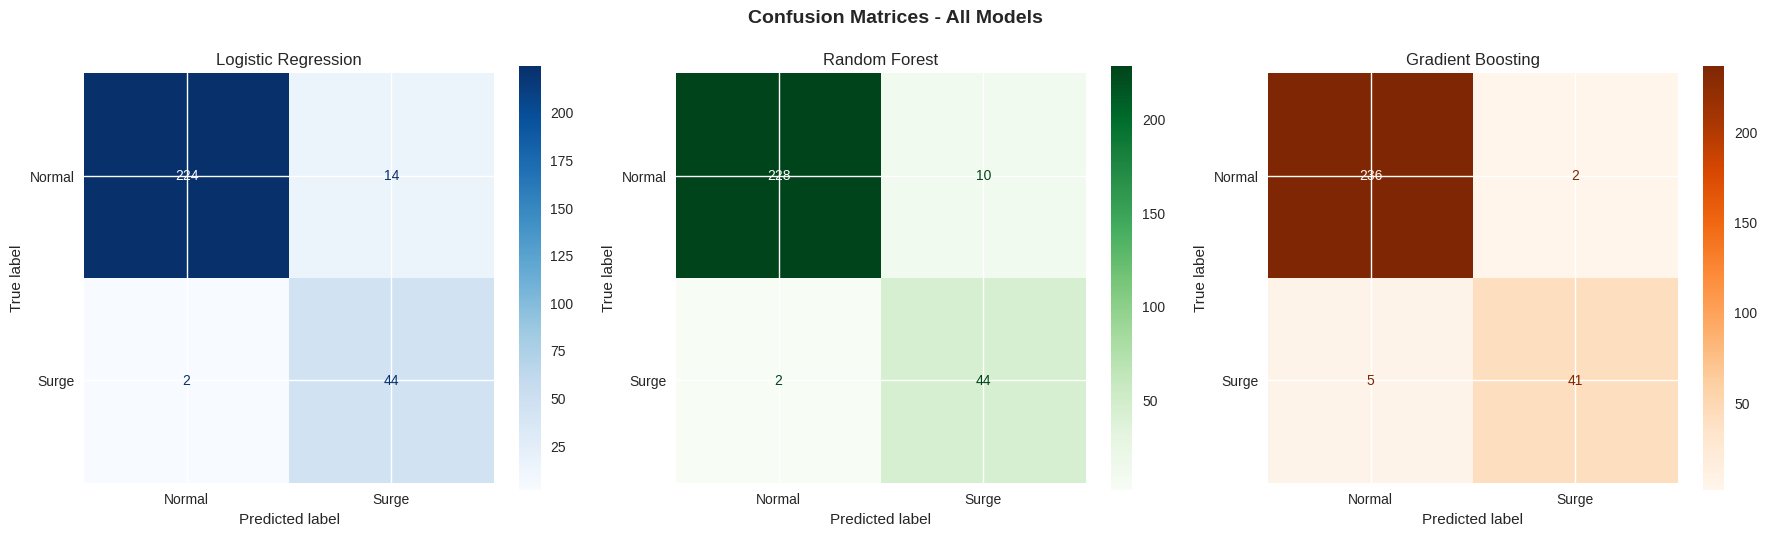

In [26]:
# =============================================================================
# 16. VISUALISATIONS
# =============================================================================
# --- 16a. Confusion Matrices (all three models) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Blues', 'Greens', 'Oranges']

for ax, (name, yp), cmap in zip(axes, all_preds.items(), cmaps):
    ConfusionMatrixDisplay.from_predictions(
        y_test, yp, display_labels=['Normal', 'Surge'],
        cmap=cmap, ax=ax
    )
    ax.set_title(f'{name}')

fig.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(PROJECT_CONFIG['output_dir'] + 'confusion_matrix.png', dpi=300,
            bbox_inches='tight')
plt.show()

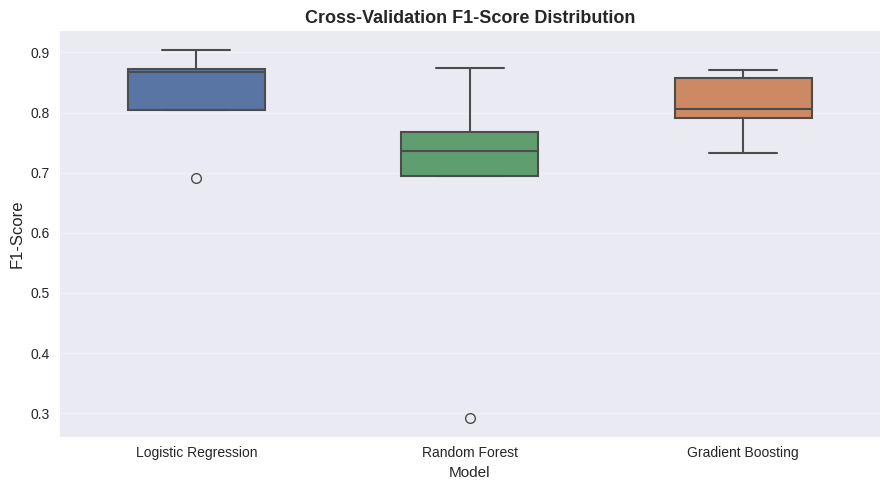

In [27]:
# --- 16b. CV Score Comparison (boxplot) ---
fig, ax = plt.subplots(figsize=(9, 5))
cv_data = pd.DataFrame({
    name: results[name]['cv_scores'] for name in results
})
cv_long = cv_data.melt(var_name='Model', value_name='F1-Score')
model_colors = {'Logistic Regression': '#4C72B0',
                'Random Forest': '#55A868',
                'Gradient Boosting': '#DD8452'}
sns.boxplot(data=cv_long, x='Model', y='F1-Score', hue='Model',
            palette=model_colors, width=0.5, linewidth=1.5, ax=ax)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Cross-Validation F1-Score Distribution', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_CONFIG['output_dir'] + 'cv_comparison.png', dpi=300)
plt.show()

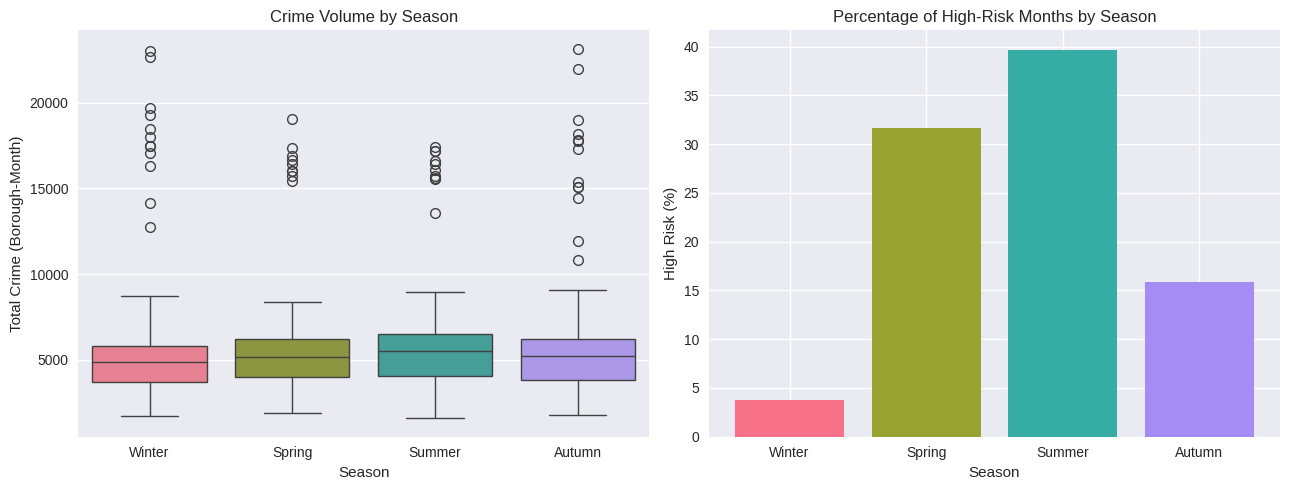

In [29]:
# --- 16c. Seasonal Crime Patterns ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# Define consistent colors for seasons
season_colors_list = sns.color_palette("husl", 4)
season_color_map = dict(zip(season_order, season_colors_list))

sns.boxplot(data=df_agg, x='season', y='total_crime', order=season_order, ax=axes[0], palette=season_color_map)
axes[0].set_title('Crime Volume by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Total Crime (Borough-Month)')

seasonal_risk = (df_agg.groupby('season')['high_risk'].mean() * 100).reindex(season_order)
axes[1].bar(seasonal_risk.index, seasonal_risk.values, color=[season_color_map[s] for s in seasonal_risk.index])
axes[1].set_title('Percentage of High-Risk Months by Season')
axes[1].set_ylabel('High Risk (%)')
axes[1].set_xlabel('Season')

fig.tight_layout()
fig.savefig(PROJECT_CONFIG['output_dir'] + 'seasonal_patterns.png', dpi=300)
plt.show()

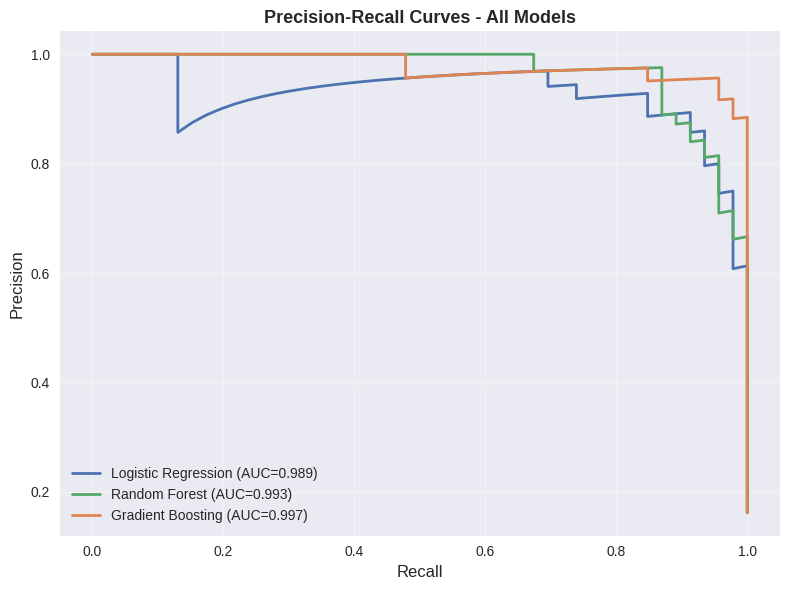

In [30]:
# --- 16d. Precision-Recall Curves (all three models) ---
fig, ax = plt.subplots(figsize=(8, 6))
model_colors = {'Logistic Regression': '#4C72B0',
                'Random Forest': '#55A868',
                'Gradient Boosting': '#DD8452'}

for name, yprob in all_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, yprob)
    auc_val = all_test_metrics[name]['test_auc']
    ax.plot(rec, prec, linewidth=2, color=model_colors[name],
            label=f'{name} (AUC={auc_val:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_CONFIG['output_dir'] + 'precision_recall_curve.png', dpi=300)
plt.show()


Running SHAP analysis...


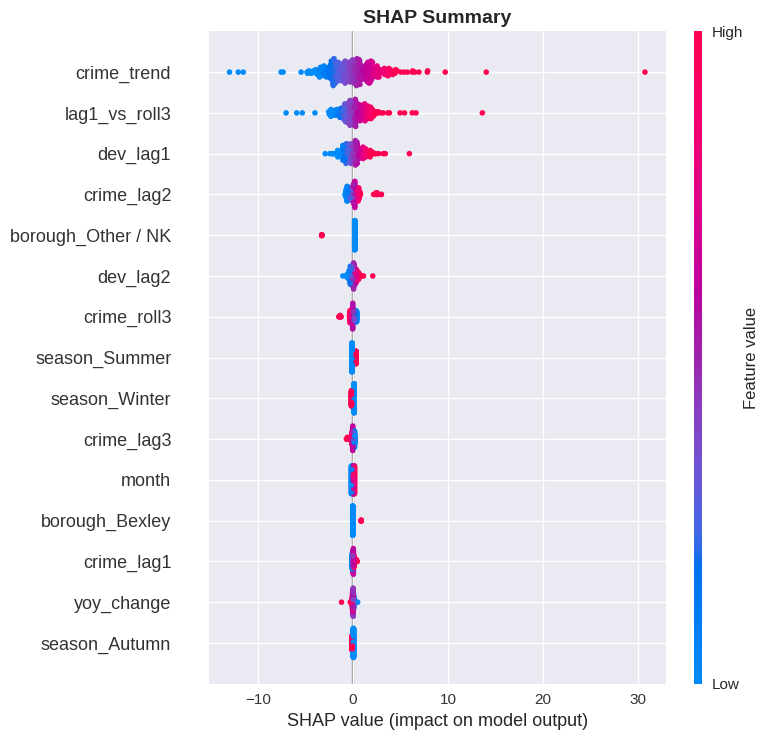

  Saved: shap_summary.png


In [47]:
# =============================================================================
# 17. EXPLAINABILITY - SHAP
# =============================================================================
print("\nRunning SHAP analysis...")

X_test_proc = best_pipeline.named_steps['preprocess'].transform(X_test)

# Build feature names from the preprocessor
cat_names = (best_pipeline.named_steps['preprocess']
             .named_transformers_['cat']
             .get_feature_names_out(categorical_features))
feature_names = list(cat_names) + numeric_features

# Choose the right SHAP explainer based on model type
best_model = best_pipeline.named_steps['model']

if isinstance(best_model, (RandomForestClassifier, GradientBoostingClassifier)):
    explainer = shap.TreeExplainer(best_model)
else:
    # For Logistic Regression or any non-tree model
    explainer = shap.LinearExplainer(best_model, X_test_proc)

shap_values = explainer.shap_values(X_test_proc)

# For tree models, shap_values may be a list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_proc, feature_names=feature_names,
                  show=False, max_display=15)
plt.title('SHAP Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_CONFIG['output_dir'] + 'shap_summary.png', dpi=300,
            bbox_inches='tight')

plt.show()
print(f"  Saved: shap_summary.png")

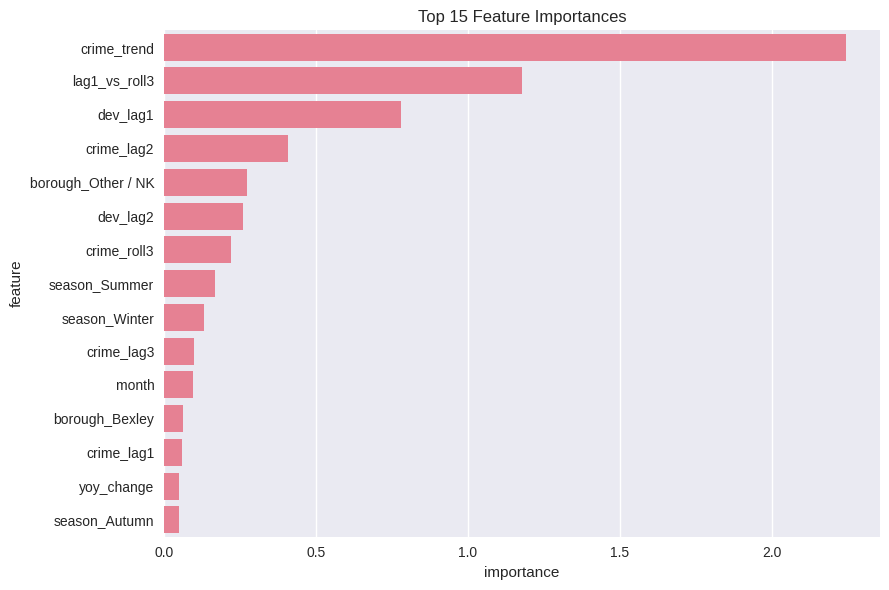

  Saved: feature_importance.png


In [43]:
# --- Feature importance bar chart ---
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(sv).mean(axis=0)

feat_imp = (pd.DataFrame({'feature': feature_names, 'importance': importances})
            .sort_values('importance', ascending=False)
            .head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', ax=ax)
ax.set_title('Top 15 Feature Importances')
fig.tight_layout()
fig.savefig(PROJECT_CONFIG['output_dir'] + 'feature_importance.png', dpi=300)
plt.show()
print(f"  Saved: feature_importance.png")

Running LIME explanation for a sample high-risk prediction...


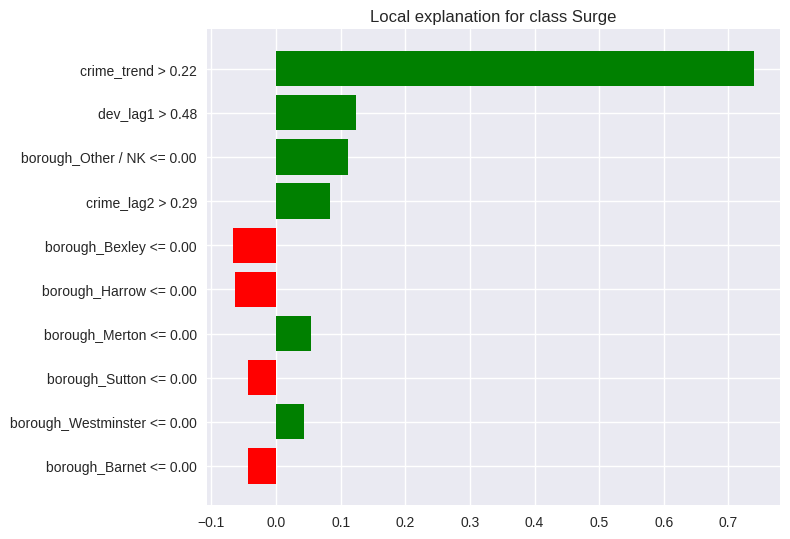

In [33]:
# =============================================================================
# 18. EXPLAINABILITY - LIME
# =============================================================================
print("Running LIME explanation for a sample high-risk prediction...")

X_train_proc = best_pipeline.named_steps['preprocess'].transform(X_train)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_proc,         # use TRAINING data as reference
    feature_names=feature_names,
    class_names=['Normal', 'Surge'],
    mode='classification'
)

# Pick first high-risk prediction in test set
high_risk_mask = (y_pred == 1)
if high_risk_mask.any():
    idx = np.where(high_risk_mask)[0][0]
    lime_exp = lime_explainer.explain_instance(
        X_test_proc[idx],
        best_pipeline.named_steps['model'].predict_proba,
        num_features=10
    )
    fig = lime_exp.as_pyplot_figure()
    fig.tight_layout()
    fig.savefig(PROJECT_CONFIG['output_dir'] + 'lime_explanation.png', dpi=300,
                bbox_inches='tight')
    plt.show()

In [34]:
# =============================================================================
# 19. STUDENT SAFETY DASHBOARD (Addresses RQ2)
# =============================================================================
print("\nGenerating Student Safety Dashboard...")

# Score every borough-month in the dataset
X_full = df_agg[FEATURE_COLS].copy()
full_probs = best_pipeline.predict_proba(X_full)[:, 1]

risk_report = df_agg[['borough', 'year', 'month', 'date',
                       'total_crime', 'top_risk_cat', 'crime_deviation']].copy()
risk_report['surge_probability'] = full_probs
risk_report['risk_level'] = pd.cut(
    full_probs, bins=[0, 0.3, 0.6, 1.0],
    labels=['LOW', 'MODERATE', 'HIGH']
)


Generating Student Safety Dashboard...


In [35]:
# Exclude 'OTHER' risk category — not relevant for student safety analysis
risk_report = risk_report[risk_report['top_risk_cat'] != 'OTHER'].copy()

# University-relevant London boroughs
UNIVERSITY_BOROUGHS = [
    'Camden', 'Westminster', 'Islington', 'Southwark', 'Lambeth',
    'Tower Hamlets', 'Kensington and Chelsea', 'Newham',
    'Hammersmith and Fulham', 'Greenwich', 'Hackney'
]
risk_report['university_area'] = risk_report['borough'].isin(UNIVERSITY_BOROUGHS)


In [36]:
# Latest available period for university boroughs
latest_date = risk_report['date'].max()
latest_uni = (risk_report[(risk_report['date'] == latest_date) &
                          (risk_report['university_area'])]
              .sort_values('surge_probability', ascending=False))

print(f"\nUniversity Borough Risks - {latest_date.strftime('%B %Y')}:")
print(latest_uni[['borough', 'risk_level', 'surge_probability', 'crime_deviation',
                   'total_crime', 'top_risk_cat']].to_string(index=False))

# Save reports
risk_report.to_csv(PROJECT_CONFIG['output_dir'] + 'full_risk_report.csv', index=False)
latest_uni.to_csv(PROJECT_CONFIG['output_dir'] + 'student_safety_report.csv', index=False)


University Borough Risks - December 2025:
Empty DataFrame
Columns: [borough, risk_level, surge_probability, crime_deviation, total_crime, top_risk_cat]
Index: []


In [37]:
# Priority alerts: high-risk university boroughs with knife/sexual/weapon crime
priority = risk_report[
    (risk_report['risk_level'] == 'HIGH') &
    (risk_report['university_area']) &
    (risk_report['top_risk_cat'].isin(['KNIFE_CRIME', 'SEXUAL_OFFENCES', 'WEAPON_CRIME']))
].nlargest(10, 'surge_probability')

if len(priority) > 0:
    print("\nPriority Alerts (High-risk university areas, serious crime):")
    for _, row in priority.iterrows():
        print(f"  {row['top_risk_cat']:20s} | {row['borough']:30s} | "
              f"{row['month']:02d}/{row['year']} | "
              f"Risk: {row['surge_probability']:.1%}")

In [44]:
# =============================================================================
# 20. SAVE MODEL & OUTPUTS
# =============================================================================
joblib.dump(best_pipeline, PROJECT_CONFIG['output_dir'] + 'best_crime_model.pkl')

print(f"\nAll outputs saved to: {PROJECT_CONFIG['output_dir']}")
print("  - model_comparison.csv")
print("  - confusion_matrix.png")
print("  - cv_comparison.png")
print("  - seasonal_patterns.png")
print("  - precision_recall_curve.png")
print("  - shap_summary.png")
print("  - feature_importance.png")
print("  - lime_explanation.png")
print("  - full_risk_report.csv")
print("  - student_safety_report.csv")
print("  - best_crime_model.pkl")


All outputs saved to: /content/drive/MyDrive/Dissertation/Output/
  - model_comparison.csv
  - confusion_matrix.png
  - cv_comparison.png
  - seasonal_patterns.png
  - precision_recall_curve.png
  - shap_summary.png
  - feature_importance.png
  - lime_explanation.png
  - full_risk_report.csv
  - student_safety_report.csv
  - best_crime_model.pkl


In [39]:
# =============================================================================
# 21. EXECUTIVE SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("EXECUTIVE SUMMARY")
print("=" * 70)
print(f"""
AIM ACHIEVED:
  Compared 3 supervised ML models; {best_model_name} achieved
  best CV F1 = {results[best_model_name]['f1_mean']:.3f}, test F1 = {metrics['F1-Score']:.3f}

OBJECTIVES:
  1. Collected & preprocessed MPS data (Mar 2022 - Feb 2026,
     {df_all['borough'].nunique()} boroughs, {df_all['date'].nunique()} months)
  2. Implemented Logistic Regression, Random Forest, Gradient Boosting
     with SHAP and LIME interpretability
  3. Evaluated using F1, ROC-AUC, Accuracy + TimeSeriesSplit CV

RESEARCH QUESTIONS:
  RQ1: {best_model_name} provides most accurate predictions
       (F1 = {results[best_model_name]['f1_mean']:.3f} +/- {results[best_model_name]['f1_std']:.3f})
  RQ2: Student safety report generated for {len(UNIVERSITY_BOROUGHS)} university boroughs;
       borough-level, probabilistic, prevention-focused - no individual profiling

ETHICAL COMPLIANCE:
  - No personally identifiable information used
  - Borough-month aggregation ensures anonymity
  - Prevention-focused design (awareness, not policing)
  - Full model transparency via SHAP/LIME
""")

print("Project complete.")


EXECUTIVE SUMMARY

AIM ACHIEVED:
  Compared 3 supervised ML models; Logistic Regression achieved
  best CV F1 = 0.828, test F1 = 0.846

OBJECTIVES:
  1. Collected & preprocessed MPS data (Mar 2022 - Feb 2026,
     33 boroughs, 48 months)
  2. Implemented Logistic Regression, Random Forest, Gradient Boosting
     with SHAP and LIME interpretability
  3. Evaluated using F1, ROC-AUC, Accuracy + TimeSeriesSplit CV

RESEARCH QUESTIONS:
  RQ1: Logistic Regression provides most accurate predictions
       (F1 = 0.828 +/- 0.076)
  RQ2: Student safety report generated for 11 university boroughs;
       borough-level, probabilistic, prevention-focused - no individual profiling

ETHICAL COMPLIANCE:
  - No personally identifiable information used
  - Borough-month aggregation ensures anonymity
  - Prevention-focused design (awareness, not policing)
  - Full model transparency via SHAP/LIME

Project complete.
